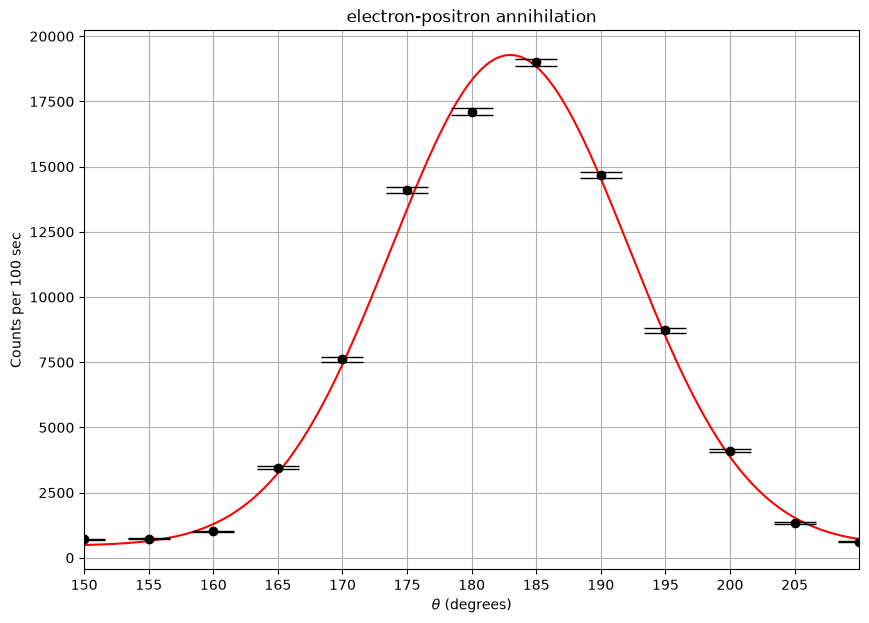

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# READ THE ARCHIVE
with open("electron_positron_annihilation.txt") as file:
    lines = file.readlines()

# REMOVE THE FIRST LINE (titles)
# CONVERT DATA IN NUMBERS AND SAVE THEM IN TWO LISTS
theta = []
counts = []

for line in lines[1:]:
    values = line.split()

    theta.append(float(values[0]))
    counts.append(float(values[1]))

# CONVERT THEM AS ARRAYS IN ORDER TO MADE CALCULATIONS
theta = np.array(theta)
counts = np.array(counts)

# CALCULATE THE STATISTICAL UNCERTAINTY (Poisson statistics)
counts_error = np.sqrt(counts)

# APPLY A GAUSSIAN FIT TO OBTAIN A SMOOTH CURVE  
def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

# SET INITIAL PARAMETER ESTIMATES FOR THE GAUSSIAN FIT
p0 = [
    max(counts) - min(counts),
    theta[np.argmax(counts)],
    5,
    min(counts)
]

# FIT THE GAUSSIAN FUNCTION TO THE EXPERIMENTAL DATA
popt, pcov = curve_fit(
    gaussian,
    theta,
    counts,
    p0=p0,
    sigma=counts_error,
    absolute_sigma=True
)

theta_smooth = np.linspace(theta.min(), theta.max(), 1000)
counts_smooth = gaussian(theta_smooth, *popt)

fig,graph = plt.subplots(figsize=(10,7), layout='none')
graph.plot(theta_smooth,counts_smooth, color="red")
graph.errorbar(theta, counts, yerr=counts_error, fmt='o', capsize=15, color="black")
graph.set_xlabel(r"$\theta$ (degrees)")
graph.set_ylabel("Counts per 100 sec")
graph.set_xlim(150,210)
plt.xticks(np.arange(150,210, 5))


graph.set_title("electron-positron annihilation")

plt.grid()
plt.show()
